In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
boundary_path = Path(
    "../data/raw/boundaries/waterloo_municipal_boundaries.geojson"
)

print(boundary_path.exists())

True


In [3]:
municipalities = gpd.read_file(boundary_path)

In [4]:
municipalities.head()

,OBJECTID,Municipality,FullName,geometry
0,1,Cambridge,City of Cambridge,"POLYGON ((-80.29468 43.44864, -80.29474 43.448..."
1,2,Kitchener,City of Kitchener,"POLYGON ((-80.46455 43.5013, -80.46468 43.5020..."
2,3,North Dumfries,Township of North Dumfries,"POLYGON ((-80.20343 43.38814, -80.20369 43.388..."
3,4,Waterloo,City of Waterloo,"POLYGON ((-80.47142 43.51627, -80.47035 43.516..."
4,5,Wellesley,Township of Wellesley,"POLYGON ((-80.63484 43.5998, -80.63493 43.5998..."


In [5]:
municipalities = gpd.read_file(boundary_path)

In [6]:
municipalities.shape

(7, 4)

In [7]:
municipalities.columns

Index(['OBJECTID', 'Municipality', 'FullName', 'geometry'], dtype='str')

In [8]:
municipalities.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [9]:
municipalities.geometry.geom_type.value_counts()

Polygon    7
Name: count, dtype: int64

In [10]:
municipalities["FullName"]

0             City of Cambridge
1             City of Kitchener
2    Township of North Dumfries
3              City of Waterloo
4         Township of Wellesley
5            Township of Wilmot
6          Township of Woolwich
Name: FullName, dtype: str

In [11]:
municipalities.geometry.geom_type.value_counts()

Polygon    7
Name: count, dtype: int64

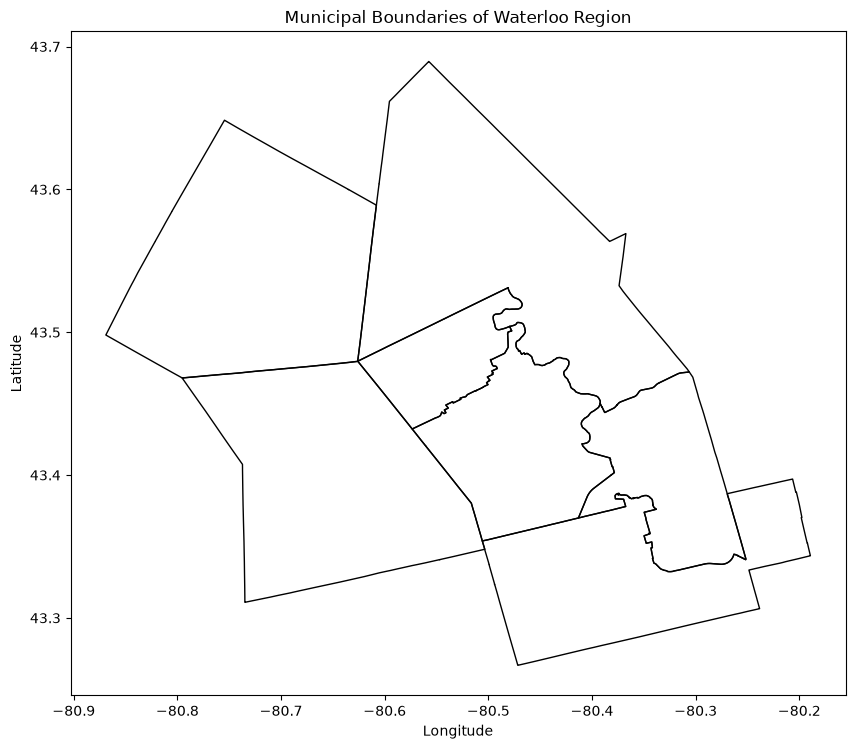

In [12]:
municipalities.plot(
    figsize=(10, 10),
    edgecolor="black",
    facecolor="none"
)

plt.title("Municipal Boundaries of Waterloo Region")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [13]:
gtfs_path = Path("../data/raw/gtfs")

stops = pd.read_csv(gtfs_path / "stops.txt")

transit_stops = stops[
    stops["location_type"] == 0
].copy()

stops_gdf = gpd.GeoDataFrame(
    transit_stops,
    geometry=gpd.points_from_xy(
        transit_stops["stop_lon"],
        transit_stops["stop_lat"]
    ),
    crs="EPSG:4326"
)

In [14]:
print("Number of transit stops:", len(stops_gdf))
print("Stops CRS:", stops_gdf.crs)

Number of transit stops: 2246
Stops CRS: EPSG:4326


In [15]:
print("Stops CRS:")
print(stops_gdf.crs)

print("\nMunicipalities CRS:")
print(municipalities.crs)

Stops CRS:
EPSG:4326

Municipalities CRS:
EPSG:4326


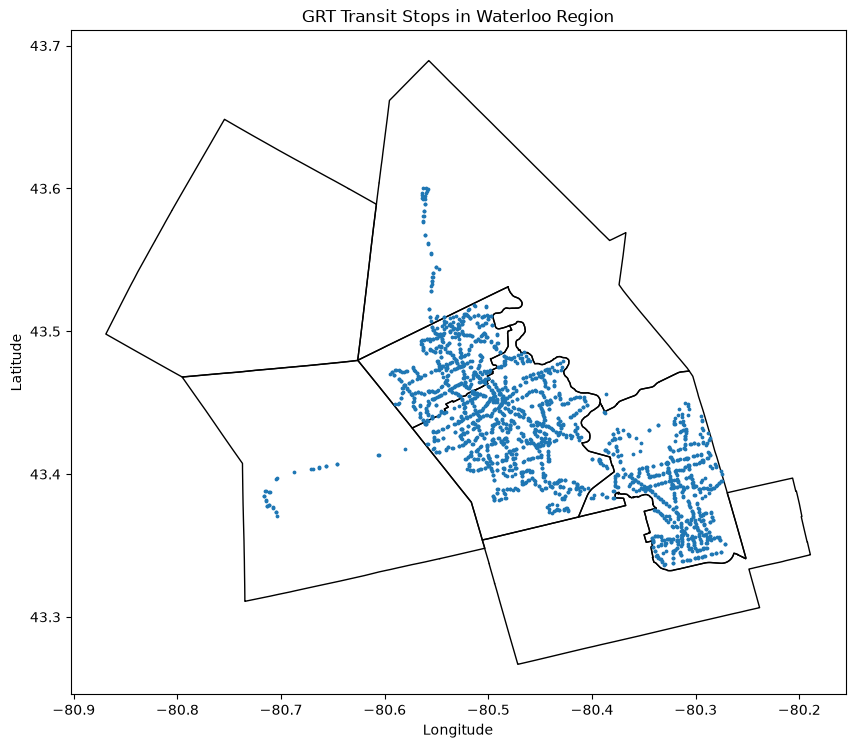

In [16]:
fig, ax = plt.subplots(figsize=(10, 10))

municipalities.plot(
    ax=ax,
    edgecolor="black",
    facecolor="none",
    linewidth=1
)

stops_gdf.plot(
    ax=ax,
    markersize=3
)

plt.title("GRT Transit Stops in Waterloo Region")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [17]:
target_crs = "EPSG:26917"

stops_projected = stops_gdf.to_crs(target_crs)
municipalities_projected = municipalities.to_crs(target_crs)

In [18]:
print("Stops:", stops_projected.crs)
print("Municipalities:", municipalities_projected.crs)

Stops: EPSG:26917
Municipalities: EPSG:26917


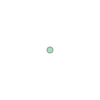

In [19]:
stops_gdf.geometry.iloc[0]

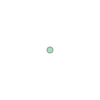

In [20]:
stops_projected.geometry.iloc[0]

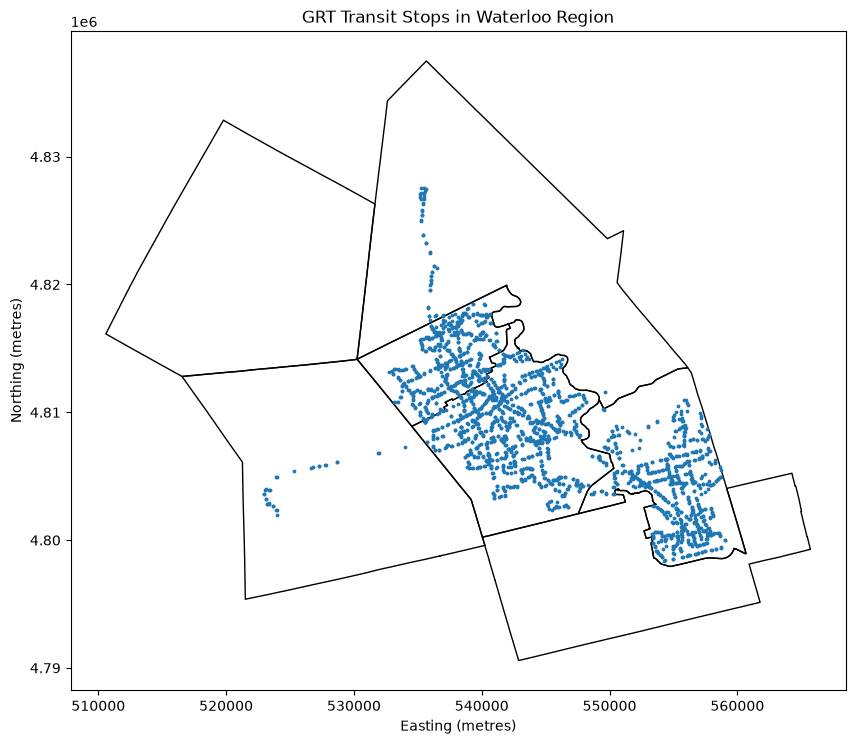

In [21]:
fig, ax = plt.subplots(figsize=(10, 10))

municipalities_projected.plot(
    ax=ax,
    edgecolor="black",
    facecolor="none",
    linewidth=1
)

stops_projected.plot(
    ax=ax,
    markersize=3
)

plt.title("GRT Transit Stops in Waterloo Region")
plt.xlabel("Easting (metres)")
plt.ylabel("Northing (metres)")
plt.show()

In [22]:
distance = stops_projected.geometry.iloc[0].distance(
    stops_projected.geometry.iloc[1]
)

print(f"Distance: {distance:.2f} metres")

Distance: 383.07 metres


In [23]:
distance = stops_projected.geometry.iloc[0].distance(
    stops_projected.geometry.iloc[1]
)

print(f"Distance: {distance:.2f} metres")

Distance: 383.07 metres


In [24]:
print("Stops CRS:", stops_projected.crs)
print("Boundary CRS:", municipalities_projected.crs)

Stops CRS: EPSG:26917
Boundary CRS: EPSG:26917


In [25]:
municipalities_projected.total_bounds

array([ 510588.71475423, 4790580.83558561,  565710.73811804,
       4837488.07229455])

In [26]:
municipalities.total_bounds

array([-80.86902761,  43.26681902, -80.18928648,  43.68955126])